# 📊 Telecom Customer Churn Prediction

## End-to-End Machine Learning Case Study

### Author
Sai Charan

---

## Business Problem

Customer churn is one of the biggest challenges faced by subscription-based telecommunication companies. Every customer who leaves the company represents not only the loss of current monthly revenue but also the loss of future revenue, customer lifetime value, and potential referrals.

Acquiring a new customer generally costs significantly more than retaining an existing one. Therefore, accurately identifying customers who are likely to discontinue their service enables the business to take proactive retention actions, optimize marketing resources, and improve long-term profitability.

This project aims to build an end-to-end machine learning solution capable of predicting customer churn using demographic information, account details, subscribed services, and billing history while following an industry-standard machine learning workflow.

# Business Objective

## Primary Objective

Develop an end-to-end machine learning solution to accurately predict whether a telecom customer is likely to churn based on demographic information, subscribed services, account history, and billing details.

The model should enable the business to proactively identify high-risk customers so that targeted retention strategies can be implemented before customers discontinue their services.

---

## Secondary Objectives

* Understand the major factors influencing customer churn.
* Identify customer segments with higher churn risk.
* Compare multiple machine learning algorithms and select the most suitable model.
* Explain model predictions using Explainable AI (SHAP).
* Build an interactive Streamlit application for churn prediction and business insights.

---

## Business Success Criteria

* Reduce customer churn by identifying high-risk customers early.
* Enable targeted retention campaigns instead of contacting every customer.
* Improve the efficiency of marketing and customer retention budgets.
* Protect customer lifetime value by preventing avoidable customer loss.

---

## Machine Learning Success Criteria

* Develop a model with strong generalization performance on unseen data.
* Prioritize Recall and F1-Score to minimize missed churn cases.
* Maintain a balance between business performance and model interpretability.
* Build a reproducible machine learning pipeline suitable for deployment.

---

## Stakeholders

* Telecom Company Management
* Marketing Team
* Customer Retention Team
* Customer Support Team
* Business Analysts
* Data Science Team

---

## Project Scope

This project focuses on predicting customer churn using historical customer information available in the Telco Customer Churn dataset. The project includes data preprocessing, exploratory data analysis, feature engineering, model development, model evaluation, explainability, and deployment through a Streamlit web application.

---

## Out of Scope

* Real-time streaming predictions
* Customer lifetime value prediction
* Revenue forecasting
* Marketing campaign optimization
* Automatic retention decision-making


In [156]:
import warnings 
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [157]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [158]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [160]:
df.shape

(7043, 21)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [162]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [164]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [165]:
df.dropna(inplace=True)

**Observation**

Only the TotalCharges column contained missing values (11 records, 0.16% of the dataset).

**Decision**

Since the missing proportion was extremely small and corresponded to newly joined customers, the affected rows were removed instead of imputing values to avoid introducing artificial information.



In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

**Impact**

Final dataset size: 7032 rows × 21 columns with no missing values.

### EXPLORATORY DATA ANALYSIS (EDA)

In [167]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [168]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

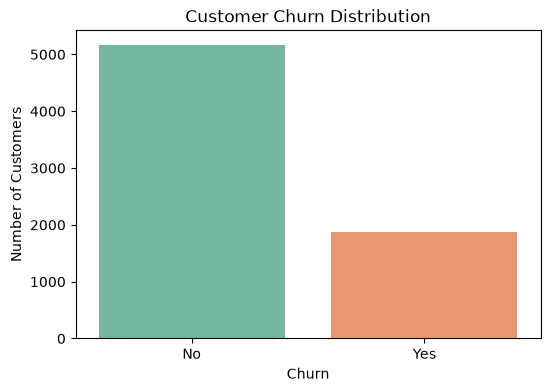

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df,
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

**Target Variable Analysis**

*Observation*:

The dataset contains approximately 73% non-churned customers and 27% churned customers.
The target variable exhibits a moderate class imbalance, which is common in real-world customer retention datasets.

*Business Interpretation*:

Roughly one in four customers discontinue the service.
This represents a substantial potential revenue loss, reinforcing the importance of early churn prediction.
Since the minority class (churned customers) is the primary business interest, model evaluation should prioritize Recall, F1-score, and ROC-AUC rather than Accuracy alone

In [170]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


### Numerical Feature Summary

#### Objective

Understand the statistical distribution of numerical variables before performing visualization or outlier analysis.

#### Observation

Count confirms no missing values remain.
Mean and median help assess skewness.
Minimum and maximum values provide the data range.
Quartiles help understand the spread of customer behavior.

#### Business Interpretation

Understanding the distribution of customer tenure and billing amounts helps identify spending patterns and customer segments that may influence churn.

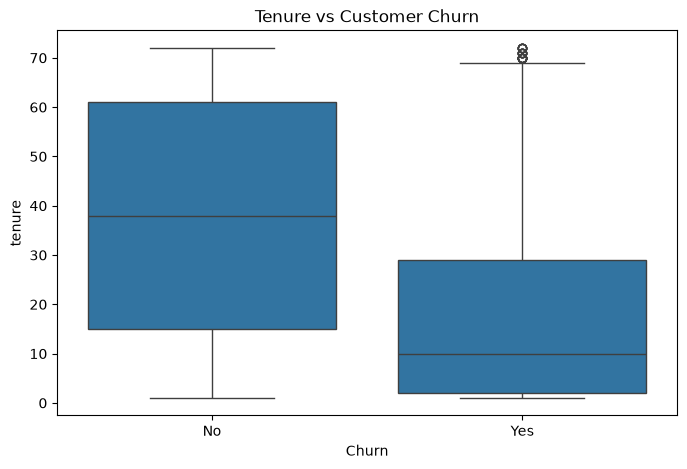

In [171]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Customer Churn")
plt.show()

### Observation
Customers who churn have a significantly lower median tenure than customers who remain with the company.
The majority of churned customers leave within the early months of their subscription.
A few long-tenure customers also churn, but they represent a small portion of the churned population.
### Business Interpretation
Customer churn is strongly associated with shorter tenure.
The first year of a customer's journey appears to be the highest-risk period.
The company should prioritize onboarding, engagement, and early retention strategies for new customers while continuing to monitor long-term customers for unexpected churn risk.

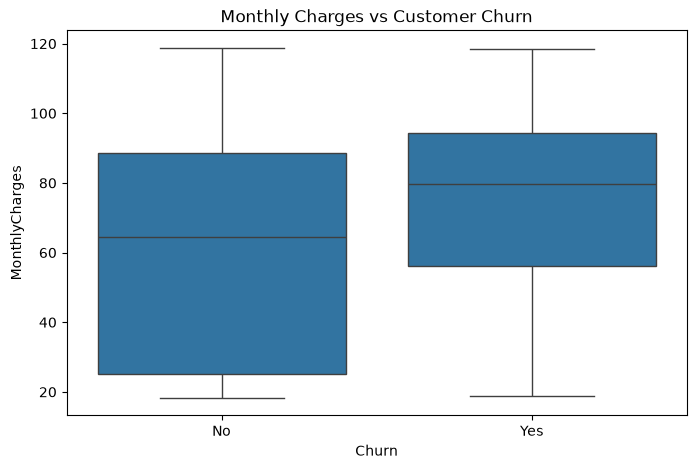

In [172]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Customer Churn")
plt.show()

### Observation
Customers who churn generally have higher monthly charges than customers who remain with the company.
However, there is considerable overlap between the two groups, indicating that MonthlyCharges alone is insufficient to predict churn.
### Business Interpretation
Higher-priced plans may increase churn risk if customers do not perceive sufficient value.
Pricing alone does not explain churn; other factors such as tenure, contract type, and service quality are also likely to influence customer decisions.
Retention efforts should prioritize customers who are both new and paying higher monthly charges, as they appear to represent a higher-risk segment.

## Contract Type vs Customer Churn

In [173]:
# Contract Distribution

df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [174]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [175]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


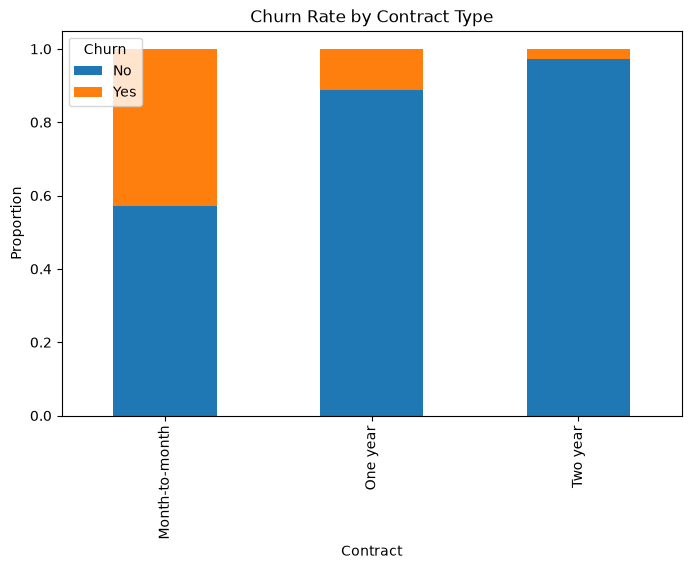

In [176]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
      normalize="index"
)

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Proportion")
plt.title("Churn Rate by Contract Type")
plt.show()

### Observation
Customers with month-to-month contracts exhibit the highest churn rate (42.7%).
Customers with one-year contracts have a significantly lower churn rate (11.3%).
Customers with two-year contracts have the lowest churn rate (2.8%).
### Business Interpretation
Contract duration is strongly associated with customer retention.
Longer contract commitments substantially reduce churn risk.
Customers on flexible month-to-month plans represent the highest-risk segment and should be prioritized for retention efforts.
### Recommendation
Encourage satisfied month-to-month customers to transition to annual or two-year plans through loyalty rewards, bundled services, or pricing incentives.
Focus retention campaigns on month-to-month customers, especially those who are also new customers or paying higher monthly charges.

## 🛠️ Tech Support vs Customer Churn

In [177]:
df["TechSupport"].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [178]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"]
)

Churn,No,Yes
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


In [179]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


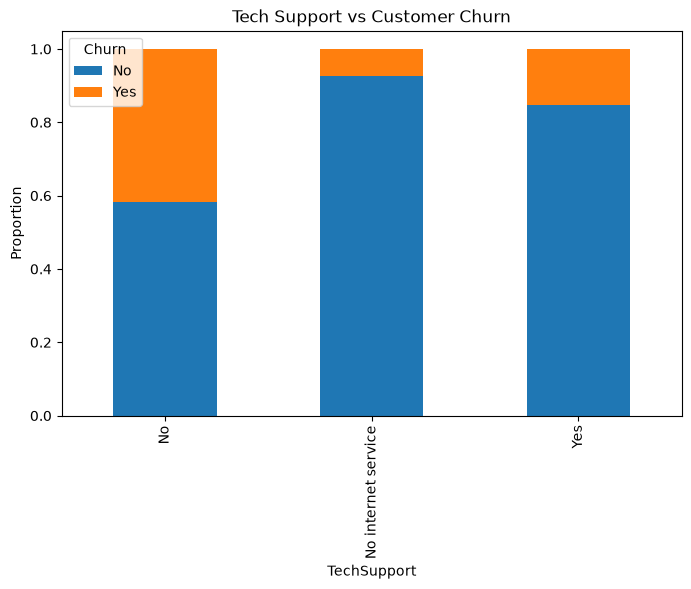

In [180]:
tech_support = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)

tech_support.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Proportion")
plt.title("Tech Support vs Customer Churn")
plt.show()

### Observation

Customers without Technical Support exhibit the highest churn rate (41.6%). Customers with Technical Support have a considerably lower churn rate (15.2%), while customers without Internet Service show the lowest churn rate (7.4%). This indicates a clear difference in churn behavior across the three customer groups.

### Business Interpretation

The availability of Technical Support is strongly associated with customer retention. Customers who do not subscribe to Technical Support are significantly more likely to discontinue the service. However, this relationship should be interpreted carefully, as other factors such as contract type, tenure, and monthly charges may also contribute to customer churn. The "No Internet Service" category represents customers for whom Technical Support is not applicable rather than customers who declined the service.

### Recommendation

Prioritize retention campaigns for customers who do not have Technical Support, particularly those on month-to-month contracts or with low tenure. Rather than providing free Technical Support to every customer, offer it strategically to high-risk customers identified by the machine learning model to maximize customer retention while controlling operational costs.

## 🌐 InternetService vs Customer Churn

In [181]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [182]:
pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [183]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


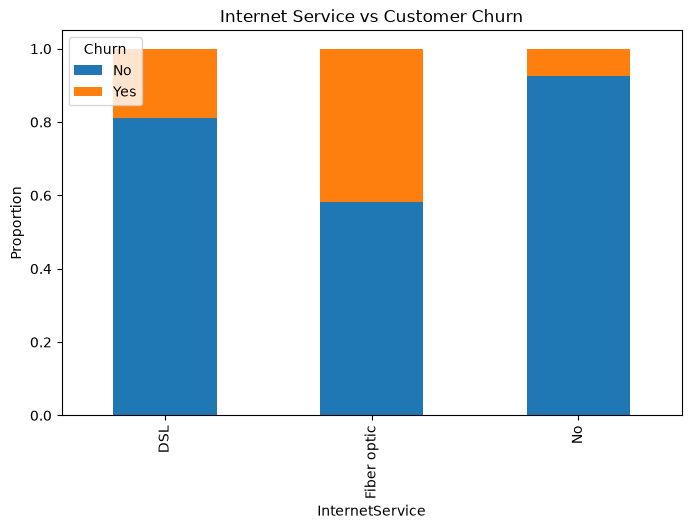

In [184]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)

internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Proportion")
plt.title("Internet Service vs Customer Churn")
plt.show()

### Observation

Customers using Fiber Optic internet exhibit the highest churn rate (41.9%), while DSL customers have a considerably lower churn rate (19.0%). Customers without internet service show the lowest churn rate (7.4%).

### Business Interpretation

The type of internet service appears to be strongly associated with customer churn. Fiber Optic customers are substantially more likely to discontinue the service compared to DSL customers. However, this relationship should not be interpreted as a direct cause of churn, as other variables such as monthly charges, contract type, tenure, and technical support may also influence customer retention.

### Recommendation

Conduct further analysis to identify why Fiber Optic customers churn more frequently. Instead of assuming the technology is the problem, investigate related factors such as pricing, contract flexibility, customer support quality, and customer tenure. Retention campaigns should focus on high-risk Fiber Optic customers identified by the machine learning model.

In [185]:
# Dropping customer identifier
df = df.drop(columns=["customerID"])

customerID is a unique identifier and does not describe customer behavior. Since it carries no predictive information and cannot generalize to unseen customers, it is removed before model training.

In [186]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

corr = df_encoded.corr()

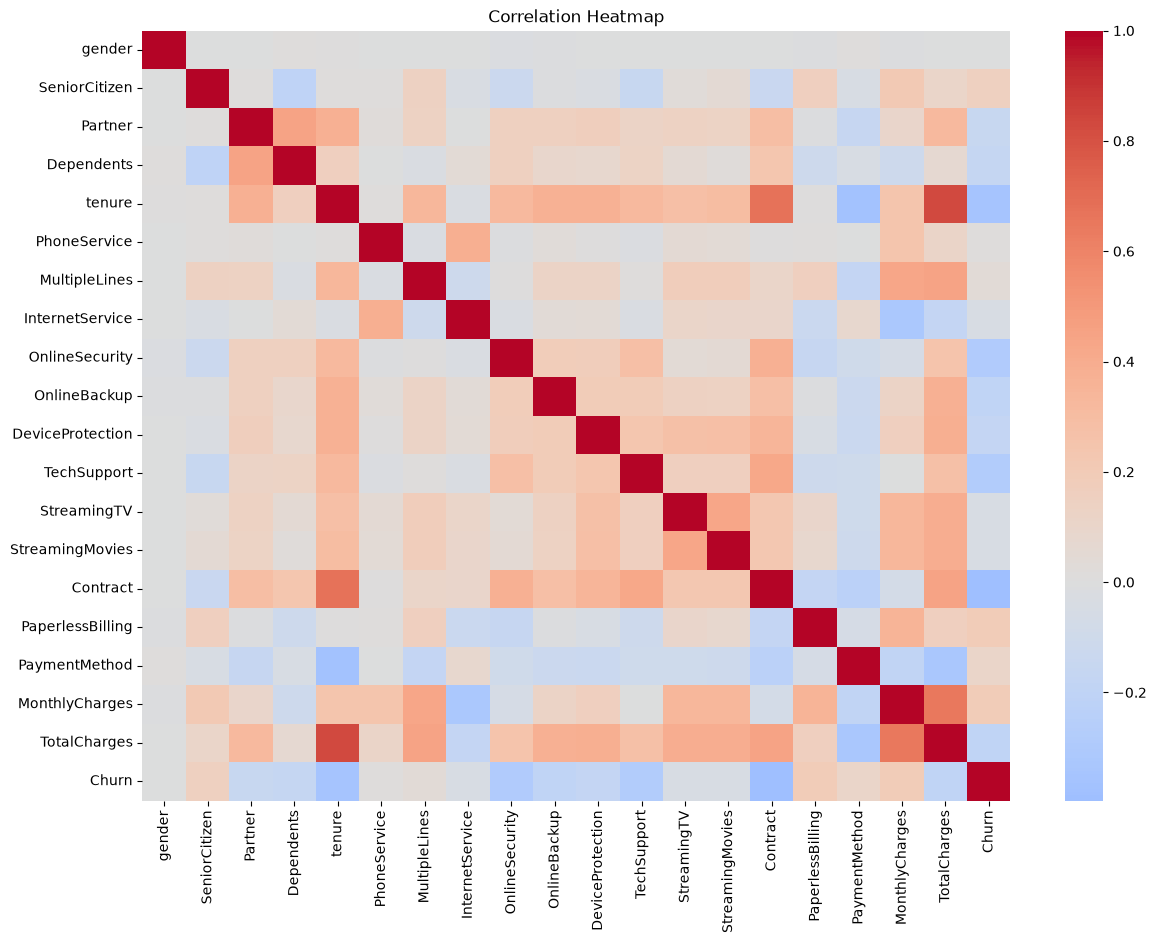

In [187]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [188]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')


In [189]:
df.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

# Feature and Target Separation

## Why is this step necessary?

In supervised machine learning, the model learns patterns from the input features (X) to predict the target variable (y). Therefore, the target variable must be separated from the feature set before model training.

Keeping the target variable within the input features would expose the correct answers during training, resulting in meaningless learning and unrealistic model performance.

## Implementation

- **Features (X):** All customer attributes used for prediction.
- **Target (y):** Customer churn status (`churn`).

This separation forms the foundation of the supervised learning workflow.

In [190]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [191]:
X

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [192]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: churn, Length: 7032, dtype: object

# Train-Test Split

## Objective

Before training any machine learning model, the dataset is divided into two parts:

- **Training Set:** Used to train the model and learn patterns from historical data.
- **Testing Set:** Used only after training to evaluate how well the model performs on unseen data.

Keeping a separate test set provides an unbiased estimate of the model's real-world performance and helps detect overfitting.

## Why is this step important?

If the model is evaluated on the same data it was trained on, the performance metrics will be overly optimistic because the model has already seen those examples.

By reserving unseen data for testing, we simulate how the model will perform when predicting churn for new customers.

## Implementation

The dataset is split into:

- **80% Training Data**
- **20% Testing Data**

Additionally, **Stratified Sampling** is used to preserve the original class distribution of the target variable in both training and testing datasets.

This is particularly important because the churn dataset is imbalanced, with approximately **73% non-churn** and **27% churn** customers.

## Expected Outcome

- Separate training and testing datasets
- Preserve class distribution in both datasets
- Prepare the data for preprocessing without introducing data leakage

In [193]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [194]:
X_train

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
1413,Male,0,Yes,Yes,65,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),94.55,6078.75
7003,Male,0,No,No,26,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,35.75,1022.50
3355,Female,0,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),90.20,6297.65
4494,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,No,Electronic check,84.30,235.05
3541,Female,0,Yes,No,49,No,No phone service,DSL,Yes,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,Male,1,Yes,No,65,Yes,No,Fiber optic,No,No,No,No,No,No,One year,Yes,Bank transfer (automatic),70.95,4555.20
5123,Female,1,No,No,15,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.30,1147.45
4135,Female,0,Yes,Yes,36,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),92.90,3379.25
4249,Female,0,Yes,Yes,10,Yes,No,DSL,No,Yes,Yes,No,No,Yes,One year,Yes,Mailed check,65.90,660.05


# ColumnTransformer

## Objective

Real-world datasets usually contain both numerical and categorical features. These feature types require different preprocessing techniques before model training.

- Numerical features are typically scaled to ensure comparable ranges.
- Categorical features must be converted into numerical representations using encoding techniques.

Applying the same preprocessing method to every column is inappropriate because each feature type has different characteristics.

## Why use ColumnTransformer?

`ColumnTransformer` enables different preprocessing operations to be applied to different groups of columns within a single workflow.

This approach:
- Reduces manual preprocessing
- Prevents mistakes
- Produces a clean and reproducible pipeline
- Integrates seamlessly with Scikit-Learn Pipelines

## Expected Outcome

Each feature receives the appropriate preprocessing method while preserving a single unified preprocessing workflow.

In [195]:
cat_cols = X_train.select_dtypes(include="object").columns

num_cols = X_train.select_dtypes(exclude="object").columns

In [196]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [197]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

Although preprocessing can be performed manually, a Pipeline automates the complete machine learning workflow by combining preprocessing and model training into a single object. This ensures that every transformation is applied in the correct order, prevents preprocessing mistakes, integrates seamlessly with cross-validation, and makes deployment much easier because new data automatically passes through the same preprocessing steps before prediction.

# Machine Learning Pipeline

## Objective

A Machine Learning Pipeline combines all preprocessing steps and the machine learning algorithm into a single workflow.

Instead of manually preprocessing the data before every model training, the pipeline ensures that each transformation is applied automatically and consistently.

## Why use a Pipeline?

Using a Pipeline provides several advantages:

- Automates the complete machine learning workflow.
- Prevents preprocessing mistakes.
- Ensures preprocessing is applied consistently during training and prediction.
- Integrates seamlessly with Cross-Validation and Hyperparameter Tuning.
- Simplifies deployment by allowing raw customer data to be passed directly into the pipeline.

## Expected Outcome

The final pipeline will accept raw customer data, perform all necessary preprocessing internally, train the model, and generate predictions using a single object.

In [198]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [199]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

In [200]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','seniorcitizen','partner',...,'paymentmethod','monthlycharges', 'totalcharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [201]:
X_train

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
1413,Male,0,Yes,Yes,65,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),94.55,6078.75
7003,Male,0,No,No,26,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,35.75,1022.50
3355,Female,0,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),90.20,6297.65
4494,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,No,Electronic check,84.30,235.05
3541,Female,0,Yes,No,49,No,No phone service,DSL,Yes,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,Male,1,Yes,No,65,Yes,No,Fiber optic,No,No,No,No,No,No,One year,Yes,Bank transfer (automatic),70.95,4555.20
5123,Female,1,No,No,15,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.30,1147.45
4135,Female,0,Yes,Yes,36,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),92.90,3379.25
4249,Female,0,Yes,Yes,10,Yes,No,DSL,No,Yes,Yes,No,No,Yes,One year,Yes,Mailed check,65.90,660.05


In [202]:
y_pred = lr_pipeline.predict(X_test)

In [203]:
y_pred

array(['No', 'Yes', 'No', ..., 'No', 'No', 'No'],
      shape=(1407,), dtype=object)

# Model Evaluation

## Objective

After training the Logistic Regression model, its performance must be evaluated on unseen test data.

Since Customer Churn is an imbalanced classification problem, relying solely on accuracy can be misleading.

Therefore, multiple evaluation metrics will be used to assess the model from different perspectives.

In [204]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [205]:
accuracy =  accuracy_score(y_test,y_pred)
print(f'Accuracy:{accuracy:.4f}')

Accuracy:0.8038


# Accuracy Evaluation

## Objective

Accuracy measures the proportion of correctly classified observations among all predictions.

It provides an overall measure of model performance but may produce misleading results when the target classes are imbalanced.

## Why Accuracy Alone is Not Enough

In customer churn prediction, the primary objective is to identify customers who are likely to leave the company.

A model may achieve high accuracy simply by predicting the majority class while failing to identify actual churners.

Therefore, additional evaluation metrics such as Precision, Recall, F1-Score, and the Confusion Matrix are required to assess the model comprehensively.

# Precision Evaluation

## Objective

Precision measures the proportion of correctly predicted churn customers among all customers predicted as churn.

## Business Importance

Precision answers the question:

> "When the model predicts that a customer will churn, how often is it correct?"

A high precision score indicates that the company is investing retention efforts on customers who are genuinely at risk, minimizing unnecessary discounts and marketing costs.

## Business Perspective

In customer churn prediction, low precision means the company spends money retaining customers who would have stayed anyway, reducing the efficiency of retention campaigns.

In [206]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print(f"Precision: {precision:.4f}")

Precision: 0.6485


# Recall Evaluation

## Objective

Recall measures the proportion of actual churn customers that the model correctly identifies.

## Business Importance

Recall answers the question:

> "Out of all customers who were actually going to churn, how many did the model successfully identify?"

A high recall score helps the company detect most high-risk customers before they leave, allowing timely retention efforts.

## Business Perspective

In customer churn prediction, False Negatives are costly because the company loses customers without taking any preventive action. Therefore, improving Recall helps reduce customer loss and protects Customer Lifetime Value (CLV).

In [207]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print(f"Recall: {recall:.4f}")

Recall: 0.5722


# F1-Score Evaluation

## Objective

F1-Score combines Precision and Recall into a single evaluation metric by balancing both measures.

## Business Importance

F1-Score is useful when both identifying actual churn customers (Recall) and avoiding unnecessary retention efforts (Precision) are equally important.

## Business Perspective

A high F1-Score indicates that the model effectively balances customer retention and retention costs by minimizing both False Positives and False Negatives.

In [208]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6080


# Confusion Matrix

## Objective

A Confusion Matrix provides a detailed summary of classification performance by comparing the model's predictions with the actual outcomes.

Unlike Accuracy, it shows exactly where the model makes correct and incorrect predictions.

## Why is it Important?

The Confusion Matrix helps identify:

- Customers correctly identified as churners (True Positives)
- Loyal customers incorrectly predicted as churners (False Positives)
- Churn customers missed by the model (False Negatives)
- Loyal customers correctly identified (True Negatives)

## Business Perspective

For customer churn prediction, False Negatives are usually the most costly because they represent customers who leave without receiving any retention efforts.

False Positives increase marketing costs, while True Positives help protect Customer Lifetime Value (CLV).

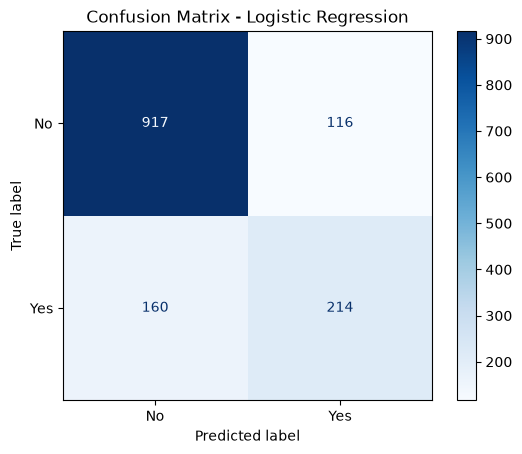

In [209]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No", "Yes"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Classification Report

## Objective

The Classification Report summarizes the key evaluation metrics of a classification model in a single table.

## Why is it Useful?

Instead of calculating Precision, Recall, and F1-Score individually, the Classification Report provides all these metrics for each class, along with overall model performance.

## Business Perspective

The report offers a comprehensive view of the model's strengths and weaknesses, helping data scientists and business stakeholders evaluate how effectively the model identifies both churn and non-churn customers.

In [210]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



# ROC-AUC Score

## Objective

ROC-AUC evaluates how well the model distinguishes between churn and non-churn customers by ranking them according to their predicted probabilities.

## Why is ROC-AUC Important?

Unlike Accuracy, Precision, and Recall, ROC-AUC evaluates the model across multiple classification thresholds instead of relying on a single decision boundary.

## Business Perspective

A high ROC-AUC score indicates that customers with a higher risk of churn are consistently ranked above customers who are unlikely to churn. This helps businesses prioritize limited retention resources toward the highest-risk customers.

In [211]:
# Predict churn probabilities

y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [212]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8359


# Decision Tree Classifier

## Objective

Decision Tree is a supervised machine learning algorithm that learns a series of decision rules by recursively splitting the data into smaller subsets.

Unlike Logistic Regression, which learns a linear decision boundary, Decision Trees can capture complex and non-linear relationships between features.

## Why Evaluate Decision Tree?

Decision Trees are simple to interpret and can model non-linear patterns effectively. However, they are prone to overfitting if allowed to grow without constraints.

By comparing the Decision Tree with Logistic Regression, we can determine whether the increased model complexity leads to meaningful improvements in churn prediction.

## Expected Outcome

Train and evaluate a Decision Tree model using the same preprocessing pipeline and compare its performance with the Logistic Regression baseline.

In [213]:
from sklearn.tree import DecisionTreeClassifier

In [214]:
dt_pipeline = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('classifier',DecisionTreeClassifier(random_state=42))
    ]
)

# Train the Decision Tree Model

## Objective

Train the Decision Tree pipeline using the training dataset.

During training, the model learns a sequence of decision rules by recursively splitting the data based on the feature that best separates churn and non-churn customers.

## Why Train on the Training Set?

The model should only learn from the training data. The test dataset must remain completely unseen until evaluation to ensure an unbiased estimate of model performance.

In [215]:
dt_pipeline.fit(X_train,y_train) 
#Find the best questions to separate churners from non-churners.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','seniorcitizen','partner',...,'paymentmethod','monthlycharges', 'totalcharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [216]:
dt_pred = dt_pipeline.predict(X_test)

In [217]:
dt_pred

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(1407,), dtype=object)

# Decision Tree Evaluation

## Objective

Evaluate the Decision Tree model using the same evaluation metrics as the Logistic Regression baseline.

Using identical evaluation metrics ensures a fair comparison between models and helps determine whether the increased model complexity improves customer churn prediction.

In [218]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

# Precision
dt_precision = precision_score(y_test, dt_pred, pos_label="Yes")

# Recall
dt_recall = recall_score(y_test, dt_pred, pos_label="Yes")

# F1 Score
dt_f1 = f1_score(y_test, dt_pred, pos_label="Yes")

# ROC-AUC
dt_prob = dt_pipeline.predict_proba(X_test)[:, 1]
dt_roc_auc = roc_auc_score(y_test, dt_prob)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")

Accuracy : 0.7306
Precision: 0.4934
Recall   : 0.4973
F1 Score : 0.4953
ROC-AUC  : 0.6565


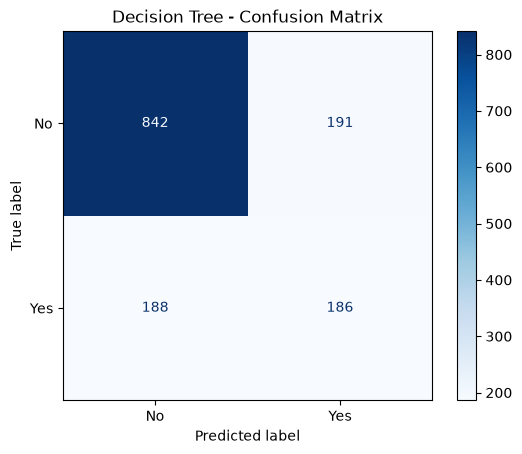

In [219]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    display_labels=["No", "Yes"],
    cmap="Blues"
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [220]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

          No       0.82      0.82      0.82      1033
         Yes       0.49      0.50      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



# Random Forest Classifier

## Objective

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Unlike a single Decision Tree, Random Forest introduces randomness by training each tree on different subsets of the data and features. The final prediction is made using majority voting.

## Why Evaluate Random Forest?

Random Forest often provides better generalization than a single Decision Tree because errors made by individual trees are averaged out across the forest.

## Expected Outcome

Train and evaluate a Random Forest model using the same preprocessing pipeline and compare its performance with previous models.

In [221]:
from sklearn.ensemble import RandomForestClassifier

In [222]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

In [223]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','seniorcitizen','partner',...,'paymentmethod','monthlycharges', 'totalcharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [224]:
r_pred = rf_pipeline.predict(X_test)

In [225]:
r_pred

array(['No', 'Yes', 'No', ..., 'No', 'No', 'No'],
      shape=(1407,), dtype=object)

## Random Forest  Evaluation

In [226]:
# Predictions
rf_pred = rf_pipeline.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

# Precision
rf_precision = precision_score(y_test, rf_pred, pos_label="Yes")

# Recall
rf_recall = recall_score(y_test, rf_pred, pos_label="Yes")

# F1 Score
rf_f1 = f1_score(y_test, rf_pred, pos_label="Yes")

# ROC-AUC
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Accuracy : 0.7875
Precision: 0.6307
Recall   : 0.4840
F1 Score : 0.5477
ROC-AUC  : 0.8137


# Baseline Model Comparison

## Objective

Compare the performance of the baseline machine learning models trained so far.

Evaluating multiple baseline models helps identify which algorithm performs best before introducing more advanced models such as XGBoost or applying feature selection and hyperparameter tuning.

At this stage, the comparison includes:

- Logistic Regression
- Decision Tree
- Random Forest

In [227]:
baseline_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

baseline_comparison = baseline_comparison.round(4)

baseline_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,Decision Tree,0.7306,0.4934,0.4973,0.4953,0.6565
2,Random Forest,0.7875,0.6307,0.4840,0.5477,0.8137


# Baseline Model Comparison Analysis

## Observation

Among the three baseline models, Logistic Regression achieved the highest overall performance across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Although Random Forest improved upon the Decision Tree by reducing overfitting and increasing predictive performance, it did not outperform Logistic Regression on this dataset.

## Business Interpretation

The customer churn patterns appear to be relatively simple and well-separated, allowing Logistic Regression to model the relationships effectively.

At the baseline stage, introducing a more complex ensemble model such as Random Forest did not provide additional predictive benefits.

## Recommendation

Based on the baseline evaluation, Logistic Regression is the preferred model because it provides the strongest balance between identifying churn customers and minimizing incorrect predictions.

However, model selection is not yet final. More advanced algorithms such as XGBoost, along with feature selection and hyperparameter tuning, will be evaluated before choosing the production model.

# XGBoost Classifier

## Objective

Train an Extreme Gradient Boosting (XGBoost) classifier to predict customer churn.

Unlike Random Forest, which builds multiple Decision Trees independently and combines them using majority voting, XGBoost builds trees sequentially. Each new tree focuses on correcting the mistakes made by the previous trees, resulting in a stronger predictive model.

## Why Evaluate XGBoost?

XGBoost is widely used for structured/tabular datasets because it often achieves high predictive performance while controlling overfitting through regularization.

## Expected Outcome

Train the XGBoost model using the same preprocessing pipeline and compare its performance with the previously trained baseline models.

In [228]:
from xgboost import XGBClassifier

In [229]:
#!pip install xgboost

# Target Variable Encoding

## Objective

Convert the target variable (`Churn`) from categorical values into numerical labels so that it can be used by the XGBoost classifier.

Unlike Logistic Regression, Decision Tree, and Random Forest in our workflow, XGBoost requires the target labels to be represented as numeric values.

## Why Label Encoding?

The target variable contains only two classes:

- No
- Yes

Label Encoding converts these classes into numerical labels:

- No → 0
- Yes → 1

This preserves the class information while satisfying the input requirements of the XGBoost algorithm.

## Expected Outcome

Create encoded versions of the training and testing target variables while ensuring that the mapping is learned only from the training data to maintain consistency throughout the machine learning pipeline.

In [230]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [231]:
y_train_encoded

array([0, 0, 0, ..., 0, 0, 1], shape=(5625,))

In [232]:
y_test_encoded 

array([0, 0, 0, ..., 0, 0, 0], shape=(1407,))

In [233]:
xgb_pipeline = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('classifier',XGBClassifier(random_state=42,eval_metric='logloss'))
    ]
)

In [234]:
xgb_pipeline.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','seniorcitizen','partner',...,'paymentmethod','monthlycharges', 'totalcharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [235]:
# Generate predictions (0 and 1)
xgb_pred = xgb_pipeline.predict(X_test)


In [236]:
xgb_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [237]:
# Convert predictions back to original labels
xgb_pred_labels = label_encoder.inverse_transform(xgb_pred)

We convert the XGBoost predictions back to "Yes" and "No" to maintain consistency with the rest of our workflow. The previous models already produce predictions in the original class labels, and our evaluation functions compare against y_test, which also contains "Yes" and "No". Using the same representation across all models makes evaluation, comparison, and interpretation much simpler.

In [238]:
xgb_pred_labels

array(['No', 'Yes', 'No', ..., 'No', 'No', 'No'],
      shape=(1407,), dtype=object)

# Evaluate XGBoost

## Objective

Evaluate the XGBoost model using the same performance metrics applied to all previous models.

Using identical evaluation metrics ensures a fair comparison between Logistic Regression, Decision Tree, Random Forest, and XGBoost.

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

## Expected Outcome

Measure the predictive performance of the XGBoost model and determine whether it outperforms the previously trained baseline models.

In [239]:
# Accuracy
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred_labels
)

# Precision
xgb_precision = precision_score(
    y_test,
    xgb_pred_labels,
    pos_label="Yes"
)

# Recall
xgb_recall = recall_score(
    y_test,
    xgb_pred_labels,
    pos_label="Yes"
)

# F1 Score
xgb_f1 = f1_score(
    y_test,
    xgb_pred_labels,
    pos_label="Yes"
)

# ROC-AUC
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_roc_auc = roc_auc_score(
    y_test_encoded,
    xgb_prob
)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

Accuracy : 0.7690
Precision: 0.5710
Recall   : 0.5267
F1 Score : 0.5480
ROC-AUC  : 0.8119


# Baseline Model Comparison

## Objective

Compare the performance of all baseline machine learning models trained in this project using a common set of evaluation metrics.

Each model has been trained using the same preprocessing pipeline and evaluated on the same unseen test dataset to ensure a fair and unbiased comparison.

## Models Compared

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

## Evaluation Metrics

The following classification metrics are used to assess each model's performance:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Using multiple evaluation metrics provides a more reliable assessment than relying on Accuracy alone, particularly because the customer churn dataset is imbalanced.

## Purpose of Comparison

The objective of this comparison is to identify the most suitable baseline model for customer churn prediction before applying feature selection and hyperparameter tuning.

Rather than selecting the most complex algorithm, the goal is to choose the model that provides the best balance between predictive performance, generalization ability, interpretability, computational efficiency, and business value.

## Expected Outcome

Determine the strongest baseline model that will serve as the reference for the optimization phase of the project.

In [240]:
Baseline_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

Baseline_comparison = Baseline_comparison.round(4)

Baseline_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,Decision Tree,0.7306,0.4934,0.4973,0.4953,0.6565
2,Random Forest,0.7875,0.6307,0.4840,0.5477,0.8137
3,XGBoost,0.7690,0.5710,0.5267,0.5480,0.8119


# Baseline Model Analysis

## Observation

Among the four baseline models, Logistic Regression achieved the strongest overall performance across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Although ensemble methods such as Random Forest and XGBoost are generally considered more advanced, they did not outperform Logistic Regression on this dataset using their default hyperparameters.

## Business Interpretation

The customer churn patterns appear to be relatively straightforward, allowing a simple linear model such as Logistic Regression to capture the underlying relationships effectively.

This demonstrates that increasing model complexity does not always result in better predictive performance.

## Conclusion

At the baseline stage, Logistic Regression is the preferred model because it provides the best balance between predictive performance, interpretability, computational efficiency, and ease of deployment.

However, this is not the final model selection. Feature importance analysis, feature selection, and hyperparameter tuning will be performed next to determine whether the performance of the tree-based models can be further improved before making the final deployment decision.

# Feature Importance Analysis

## Objective

Analyze the contribution of each feature to the model's predictions.

Feature importance helps identify which customer attributes have the greatest influence on churn prediction, allowing both machine learning engineers and business stakeholders to better understand the model's decision-making process.

## Why Perform Feature Importance?

Understanding feature importance provides several benefits:

- Improves model interpretability.
- Identifies the most influential customer characteristics.
- Supports feature selection by removing less important variables.
- Generates business insights for customer retention strategies.

## Expected Outcome

Rank the features based on their contribution to churn prediction and identify the variables that have the greatest impact on customer churn.

# Extract Transformed Feature Names

## Objective

Retrieve the names of all features after preprocessing.

Since categorical variables were transformed using One-Hot Encoding, the original dataset no longer contains the same feature structure. Extracting the transformed feature names allows us to correctly associate each feature with its corresponding Logistic Regression coefficient.

## Why is this Important?

Machine learning models are trained on the transformed dataset, not the original dataset.

Therefore, before analyzing feature importance, we must first obtain the transformed feature names to correctly interpret the model's learned coefficients.

## Expected Outcome

Generate a complete list of transformed feature names that will be used to analyze feature importance.

In [241]:
feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [242]:
feature_names

array(['num__seniorcitizen', 'num__tenure', 'num__monthlycharges',
       'num__totalcharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__partner_No', 'cat__partner_Yes', 'cat__dependents_No',
       'cat__dependents_Yes', 'cat__phoneservice_No',
       'cat__phoneservice_Yes', 'cat__multiplelines_No',
       'cat__multiplelines_No phone service', 'cat__multiplelines_Yes',
       'cat__internetservice_DSL', 'cat__internetservice_Fiber optic',
       'cat__internetservice_No', 'cat__onlinesecurity_No',
       'cat__onlinesecurity_No internet service',
       'cat__onlinesecurity_Yes', 'cat__onlinebackup_No',
       'cat__onlinebackup_No internet service', 'cat__onlinebackup_Yes',
       'cat__deviceprotection_No',
       'cat__deviceprotection_No internet service',
       'cat__deviceprotection_Yes', 'cat__techsupport_No',
       'cat__techsupport_No internet service', 'cat__techsupport_Yes',
       'cat__streamingtv_No', 'cat__streamingtv_No internet service',
       'cat__

# Extract Logistic Regression Coefficients

## Objective

Extract the learned coefficients from the trained Logistic Regression model and associate them with their corresponding transformed feature names.

Unlike tree-based models, Logistic Regression represents feature importance using coefficients. These coefficients indicate both the strength and direction of each feature's influence on customer churn.

## Why Extract Coefficients?

By combining feature names with their coefficients, we can:

- Interpret the model's decision-making process.
- Identify which features increase customer churn.
- Identify which features reduce customer churn.
- Generate meaningful business insights from the trained model.

## Expected Outcome

Create a structured table containing each transformed feature and its corresponding coefficient for further analysis.

In [243]:
coefficients = lr_pipeline.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance

,Feature,Coefficient
0,num__seniorcitizen,0.071011
1,num__tenure,-1.352313
2,num__monthlycharges,-0.541006
3,num__totalcharges,0.644014
4,cat__gender_Female,-0.142779
5,cat__gender_Male,-0.166893
6,cat__partner_No,-0.142419
7,cat__partner_Yes,-0.167253
8,cat__dependents_No,-0.039151
9,cat__dependents_Yes,-0.270520


# Analyze Feature Importance

## Objective

Rank the transformed features based on their Logistic Regression coefficients to understand which customer characteristics have the strongest influence on churn.

Positive coefficients indicate features that increase the likelihood of customer churn, while negative coefficients indicate features that reduce the likelihood of churn.

## Why Analyze the Coefficients?

Sorting the coefficients helps identify:

- Features that strongly increase churn risk.
- Features that strongly reduce churn risk.
- Key business factors influencing customer retention.
- Potential features for feature selection and model optimization.

## Expected Outcome

Generate ranked lists of the most influential positive and negative features to support business decision-making.

In [244]:
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
3,num__totalcharges,0.644014
36,cat__contract_Month-to-month,0.613846
16,cat__internetservice_Fiber optic,0.590184
32,cat__streamingtv_Yes,0.191113
43,cat__paymentmethod_Electronic check,0.180671
35,cat__streamingmovies_Yes,0.177076
18,cat__onlinesecurity_No,0.164459
27,cat__techsupport_No,0.142949
14,cat__multiplelines_Yes,0.088164
0,num__seniorcitizen,0.071011


# Identify Key Churn Drivers

## Objective

Separate the most influential positive and negative coefficients to identify which features increase customer churn and which features improve customer retention.

This analysis converts the model's learned coefficients into actionable business insights.

In [245]:
# Top 10 features that increase churn
top_positive = feature_importance.head(10)

# Top 10 features that reduce churn
top_negative = feature_importance.tail(10).sort_values(
    by="Coefficient"
)

print("Top Features Increasing Churn")
display(top_positive)

print("\nTop Features Reducing Churn")
display(top_negative)

Top Features Increasing Churn


,Feature,Coefficient
3,num__totalcharges,0.644014
36,cat__contract_Month-to-month,0.613846
16,cat__internetservice_Fiber optic,0.590184
32,cat__streamingtv_Yes,0.191113
43,cat__paymentmethod_Electronic check,0.180671
35,cat__streamingmovies_Yes,0.177076
18,cat__onlinesecurity_No,0.164459
27,cat__techsupport_No,0.142949
14,cat__multiplelines_Yes,0.088164
0,num__seniorcitizen,0.071011



Top Features Reducing Churn


,Feature,Coefficient
1,num__tenure,-1.352313
38,cat__contract_Two year,-0.779030
15,cat__internetservice_DSL,-0.616132
2,num__monthlycharges,-0.541006
39,cat__paperlessbilling_No,-0.300387
12,cat__multiplelines_No,-0.293470
28,cat__techsupport_No internet service,-0.283724
25,cat__deviceprotection_No internet service,-0.283724
17,cat__internetservice_No,-0.283724
22,cat__onlinebackup_No internet service,-0.283724


# Visualize Feature Importance

## Objective

Visualize the most influential features learned by the Logistic Regression model.

The plots highlight which customer characteristics increase churn risk and which characteristics contribute to customer retention.

## Why Visualize Feature Importance?

Although coefficient tables provide numerical values, visualizations make it easier to identify and compare the most influential features.

These charts improve model interpretability and help communicate insights to both technical and non-technical stakeholders.

## Expected Outcome

Generate separate bar charts showing:

- Top 10 features increasing customer churn.
- Top 10 features reducing customer churn.

These visualizations will be used to support business recommendations and future feature selection.

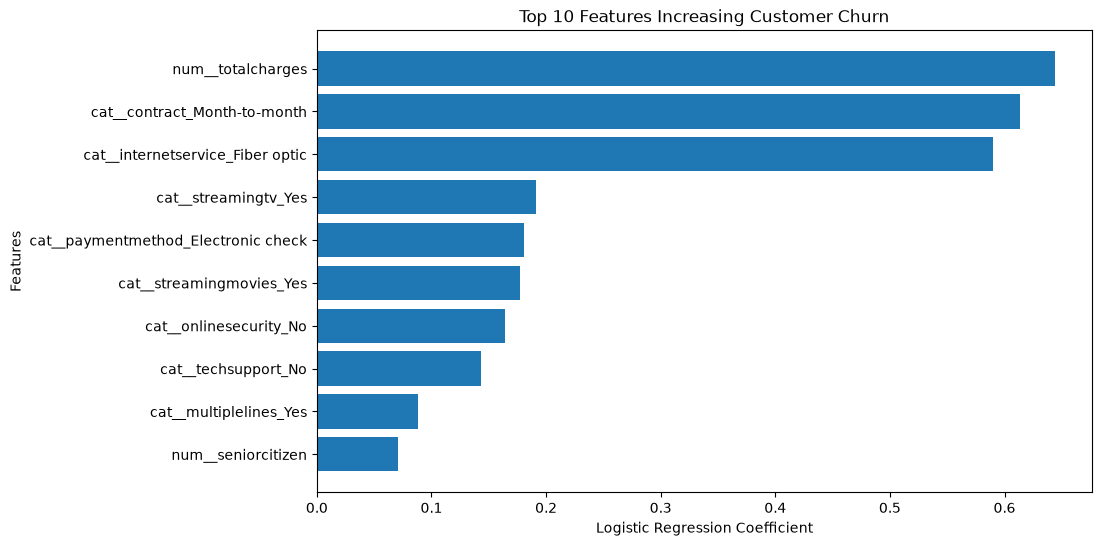

In [246]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)

plt.title("Top 10 Features Increasing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

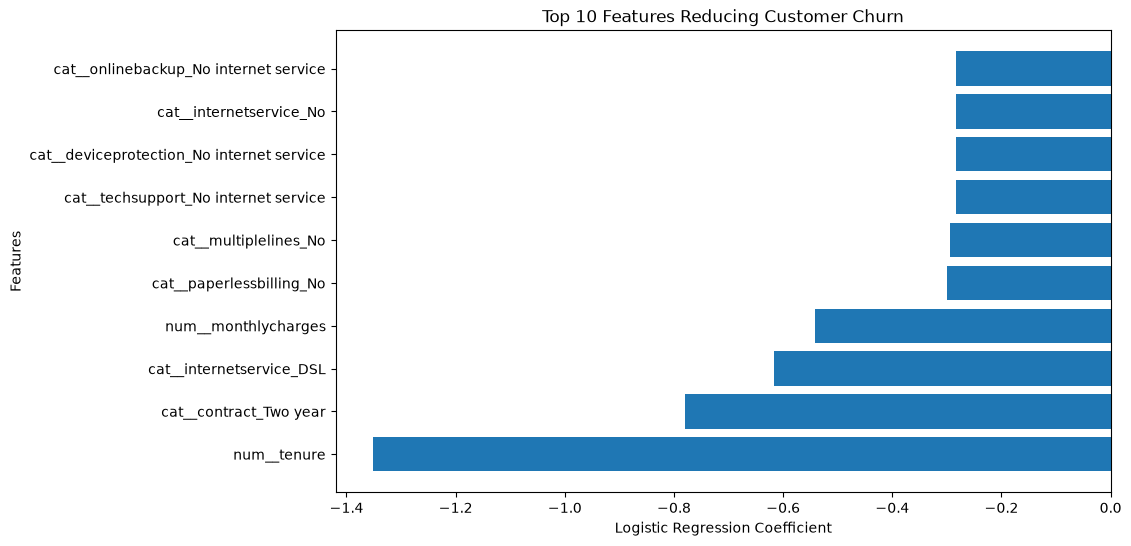

In [247]:
plt.figure(figsize=(10,6))

plt.barh(
    top_negative["Feature"],
    top_negative["Coefficient"]
)

plt.title("Top 10 Features Reducing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Features")

plt.show()

# Feature Importance Analysis

## Objective

Interpret the Logistic Regression model by analyzing and visualizing its learned coefficients.

Unlike evaluation metrics, which tell us how well the model performs, feature importance explains why the model predicts customer churn.

## Analysis Performed

The analysis includes:

- Ranking all transformed features by their learned coefficients.
- Identifying the top features that increase customer churn.
- Identifying the top features that reduce customer churn.
- Visualizing these features using horizontal bar charts for easier interpretation.

## Business Importance

Feature importance helps answer questions such as:

- Which customer characteristics are associated with higher churn?
- Which characteristics contribute to customer retention?
- Which areas should the business prioritize to improve customer retention?
- Which features may be considered for feature selection in the next phase?

It is important to note that Logistic Regression coefficients indicate the direction and strength of association with the target variable. They do **not** prove causation.

## Expected Outcome

Generate ranked tables and visualizations that highlight the most influential features affecting customer churn, providing actionable insights for both business stakeholders and future model optimization.

# Feature Selection

## Objective

Identify and retain the most informative features while removing features that contribute little to the model's predictive performance.

Feature selection helps simplify the model without sacrificing accuracy, allowing it to generalize better to unseen data.

## Why Perform Feature Selection?

Using every available feature does not always produce the best model.

Removing less informative features can:

- Reduce model complexity.
- Improve generalization.
- Reduce overfitting.
- Decrease training time.
- Improve model interpretability.

## Expected Outcome

Select the most relevant features for customer churn prediction and use them to retrain the machine learning models for comparison.

# Recursive Feature Elimination with Cross Validation (RFECV)

## Objective

Automatically determine the optimal number of features required to maximize the predictive performance of the Logistic Regression model.

Unlike Recursive Feature Elimination (RFE), which requires manually specifying the number of features to retain, RFECV uses cross-validation to identify the feature subset that produces the best model performance.

## Why RFECV?

Selecting an arbitrary number of features may remove useful information or retain unnecessary variables.

RFECV evaluates multiple feature subsets and automatically selects the number of features that provides the best balance between model complexity and predictive performance.

## Expected Outcome

Identify the optimal subset of transformed features that will be used to retrain and optimize the customer churn prediction model.

In [248]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    step=1,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train RFECV

## Objective

Train the RFECV algorithm to automatically identify the optimal subset of features for the Logistic Regression model.

RFECV recursively removes less informative features while evaluating model performance using 5-fold cross-validation and the F1-score.

## Expected Outcome

Determine the optimal number of transformed features that maximize the model's predictive performance.

In [249]:
X_train_transformed = preprocessor.fit_transform(X_train)

In [250]:
#here we temporarily extracted the transformed dataset from the preprocessor

In [251]:
rfecv.fit(
    X_train_transformed,
    y_train_encoded
)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'f1'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scor

# RFECV Results

## Objective

Examine the outcome of the Recursive Feature Elimination with Cross Validation (RFECV) process.

RFECV identifies the optimal number of features and determines which transformed features should be retained or removed based on their contribution to model performance.

## Expected Outcome

Review:

- The optimal number of selected features.
- Which features were retained.
- The ranking assigned to every transformed feature.

In [252]:
print(f"Optimal Number of Features: {rfecv.n_features_}")

print("\nSelected Features Mask:")
print(rfecv.support_)

print("\nFeature Rankings:")
print(rfecv.ranking_)

Optimal Number of Features: 26

Selected Features Mask:
[False  True  True  True False False  True  True False  True False  True
  True False False  True  True  True False  True  True False  True  True
 False  True False False  True  True  True  True False  True  True False
  True False  True  True False False False  True False]

Feature Rankings:
[16  1  1  1  6  5  1  1 18  1 13  1  1 12 14  1  1  1  2  1  1 17  1  1
 15  1 19  4  1  1  1  1 10  1  1 11  1  3  1  1 20  7  8  1  9]


# Selected Features

## Objective

Identify the transformed features retained by RFECV after feature selection.

Rather than interpreting Boolean masks, we create a structured table showing which features were selected for the optimized Logistic Regression model.

## Expected Outcome

Generate a clear list of the transformed features that will be used to retrain the optimized model.

In [253]:
selected_features = feature_names[rfecv.support_]

selected_features_df = pd.DataFrame({
    "Selected Features": selected_features
})

selected_features_df

,Selected Features
0,num__tenure
1,num__monthlycharges
2,num__totalcharges
3,cat__partner_No
4,cat__partner_Yes
5,cat__dependents_Yes
6,cat__phoneservice_Yes
7,cat__multiplelines_No
8,cat__internetservice_DSL
9,cat__internetservice_Fiber optic


# Retrain Logistic Regression Using Selected Features

## Objective

Train a new Logistic Regression model using only the features selected by RFECV.

Removing less informative features can simplify the model while maintaining or improving predictive performance.

## Why Retrain the Model?

Feature selection identifies the most informative features, but it does not automatically update the model.

A new model must be trained using only the selected features to evaluate whether feature selection improves performance.

## Expected Outcome

Train an optimized Logistic Regression model using the selected features and compare its performance with the original baseline model.

In [254]:
X_train_selected = rfecv.transform(X_train_transformed)

In [255]:
X_test_transformed = preprocessor.transform(X_test)

X_test_selected = rfecv.transform(X_test_transformed)

# Train Optimized Logistic Regression Model

## Objective

Train a new Logistic Regression model using only the features selected by RFECV.

The optimized model will be evaluated against the original baseline model to determine whether feature selection improves predictive performance.

## Why Train a New Model?

RFECV only identifies the most informative features.

A new Logistic Regression model must be trained using the reduced feature set to measure the impact of feature selection.

## Expected Outcome

Train an optimized Logistic Regression model using the selected features and compare its performance with the original baseline.

In [256]:
from sklearn.linear_model import LogisticRegression

optimized_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

optimized_lr.fit(
    X_train_selected,
    y_train_encoded
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

# Generate Predictions Using the Optimized Model

## Objective

Use the optimized Logistic Regression model to predict customer churn on the selected test features.

The predictions will be evaluated and compared with the original baseline model to determine whether feature selection improved model performance.

## Expected Outcome

Generate predictions for the optimized model and prepare them for evaluation using the same performance metrics applied throughout the project.

In [257]:
optimized_pred = optimized_lr.predict(
    X_test_selected
)

# Evaluate the Optimized Logistic Regression Model

## Objective

Evaluate the performance of the optimized Logistic Regression model trained using the features selected by RFECV.

The optimized model will be assessed using the same evaluation metrics as the baseline model to ensure a fair comparison.

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

## Expected Outcome

Measure the predictive performance of the optimized model and determine whether feature selection improved the model's ability to predict customer churn.

In [258]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
optimized_pred = optimized_lr.predict(X_test_selected)

# Prediction Probabilities
optimized_prob = optimized_lr.predict_proba(X_test_selected)[:, 1]

# Accuracy
optimized_accuracy = accuracy_score(
    y_test_encoded,
    optimized_pred
)

# Precision
optimized_precision = precision_score(
    y_test_encoded,
    optimized_pred
)

# Recall
optimized_recall = recall_score(
    y_test_encoded,
    optimized_pred
)

# F1 Score
optimized_f1 = f1_score(
    y_test_encoded,
    optimized_pred
)

# ROC-AUC
optimized_roc_auc = roc_auc_score(
    y_test_encoded,
    optimized_prob
)

print(f"Accuracy : {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall   : {optimized_recall:.4f}")
print(f"F1 Score : {optimized_f1:.4f}")
print(f"ROC-AUC  : {optimized_roc_auc:.4f}")

Accuracy : 0.7989
Precision: 0.6366
Recall   : 0.5668
F1 Score : 0.5997
ROC-AUC  : 0.8354


# Comparison: Baseline vs Optimized Logistic Regression

## Objective

Compare the performance of the original Logistic Regression model with the optimized model trained using the RFECV-selected features.

The purpose of this comparison is to evaluate whether feature selection improved predictive performance while reducing model complexity.

## Results Summary

| Metric | Baseline Logistic Regression | Optimized Logistic Regression |
|--------|-----------------------------:|------------------------------:|
| Accuracy | 0.8038 | 0.7989 |
| Precision | 0.6485 | 0.6366 |
| Recall | 0.5722 | 0.5668 |
| F1-Score | 0.6080 | 0.5997 |
| ROC-AUC | 0.8359 | 0.8354 |

## Conclusion

RFECV successfully reduced the number of transformed features from 45 to 26, simplifying the model.

However, the optimized Logistic Regression showed a slight decrease across all evaluation metrics compared to the baseline model.

Since the primary objective is to maximize predictive performance for customer churn prediction, the baseline Logistic Regression remains the preferred model for this project.

This experiment demonstrates that feature selection should be validated through experimentation rather than assumed to improve model performance.

# Select Features using Random Forest

## Objective

Use the trained Random Forest model to automatically select the most informative transformed features based on their feature importance scores.

Unlike Logistic Regression, Random Forest measures feature importance by evaluating how much each feature contributes to reducing impurity across all trees in the forest.

## Why Use SelectFromModel?

SelectFromModel automatically removes features with low importance while retaining the most informative features.

This creates a simpler feature set before Bayesian Optimization, allowing the optimization process to focus on the features that contribute most to predicting customer churn.

## Expected Outcome

Generate a reduced feature set that will be used to train and optimize the final Random Forest model.

In [259]:
#!pip install optuna

In [260]:
from sklearn.feature_selection import SelectFromModel

In [261]:
rf_selector = SelectFromModel(
    estimator = rf_pipeline.named_steps['classifier'],
    threshold= 'median'
)

# Select Important Features

## Objective

Fit the SelectFromModel transformer using the trained Random Forest model and generate a reduced feature set containing only the most informative transformed features.

The selected features will be used for Bayesian hyperparameter optimization.

## Expected Outcome

Create new training and testing datasets containing only the features selected by the Random Forest model.

In [262]:
# Fit the selector
rf_selector.fit(
    X_train_transformed,
    y_train_encoded
)

# Transform the datasets
X_train_rf_selected = rf_selector.transform(X_train_transformed)

X_test_rf_selected = rf_selector.transform(X_test_transformed)

print("Original Features :", X_train_transformed.shape[1])
print("Selected Features :", X_train_rf_selected.shape[1])

Original Features : 45
Selected Features : 23


In [263]:
rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_pipeline.named_steps["classifier"].feature_importances_
})

rf_importance_df = rf_importance_df.sort_values(
    by="Importance",
    ascending=False
)

rf_importance_df

,Feature,Importance
3,num__totalcharges,0.163614
1,num__tenure,0.141102
2,num__monthlycharges,0.134536
36,cat__contract_Month-to-month,0.051046
43,cat__paymentmethod_Electronic check,0.031814
18,cat__onlinesecurity_No,0.031001
16,cat__internetservice_Fiber optic,0.030541
27,cat__techsupport_No,0.022714
0,num__seniorcitizen,0.019752
4,cat__gender_Female,0.018498


## Observation : 

I experimented with both thresholds. Using the mean retained only 8 out of 45 features, which I found overly aggressive for a Random Forest model that benefits from feature interactions. The median retained 23 informative features, providing a better balance between reducing complexity and preserving useful predictive information. The decision was based on empirical results from my dataset rather than relying on a default choice

# Bayesian Hyperparameter Optimization using Optuna

## Objective

Optimize the Random Forest classifier by automatically searching for the best combination of hyperparameters using Bayesian Optimization.

Unlike Grid Search and Random Search, Bayesian Optimization learns from previous trials and intelligently chooses the next set of hyperparameters to evaluate, reducing unnecessary computations while improving model performance.

## Why Bayesian Optimization?

Bayesian Optimization builds a probabilistic model of the hyperparameter search space and balances:

- Exploration: Searching new regions that may contain better solutions.
- Exploitation: Refining hyperparameters around regions that have already shown good performance.

This allows the optimizer to converge towards high-performing hyperparameter combinations with fewer model evaluations.

## Expected Outcome

Identify the optimal Random Forest hyperparameters that maximize the F1-score using the selected features obtained from Random Forest feature selection.

In [264]:
import optuna

# Define the Objective Function

## Objective

Create the objective function that Optuna will optimize.

For every trial, Optuna suggests a new set of hyperparameters. The objective function trains a Random Forest model using those parameters, evaluates its performance using the F1-score, and returns the score to Optuna.

The returned F1-score acts as feedback, allowing Bayesian Optimization to learn from previous trials and intelligently search for better hyperparameter combinations.

## Expected Outcome

Define a reusable function that Optuna can repeatedly call during the optimization process.

In [265]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf,
        X_train_rf_selected,
        y_train_encoded,
        cv=5,
        scoring="f1"
    )

    return scores.mean()

# Create an Optuna Study

## Objective

Create an Optuna study that manages the Bayesian Optimization process.

The study is responsible for running multiple optimization trials, comparing their performance, remembering previous results, and identifying the best set of hyperparameters.

## Why Create a Study?

A Study is the central object in Optuna that:

- Creates and manages optimization trials.
- Stores the results of every trial.
- Learns from previous trials.
- Identifies the best hyperparameter combination.

## Expected Outcome

Initialize an Optuna study configured to maximize the F1-score returned by the objective function.

In [266]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-07-09 16:04:08,707] A new study created in memory with name: no-name-0a652b22-69f3-4e63-b0e2-0e790f168524


# Run Bayesian Optimization

## Objective

Execute the Bayesian Optimization process by allowing Optuna to repeatedly call the objective function.

For each trial, Optuna proposes a new set of Random Forest hyperparameters, trains the model, evaluates its F1-score using cross-validation, and learns from the result before selecting the next trial.

## Expected Outcome

Search for the optimal combination of Random Forest hyperparameters that maximizes the cross-validated F1-score.

In [267]:
study.optimize(
    objective,
    n_trials=50
)

[I 2026-07-09 16:04:15,981] Trial 0 finished with value: 0.5884972126131569 and parameters: {'n_estimators': 107, 'max_depth': 14, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.5884972126131569.
[I 2026-07-09 16:04:27,882] Trial 1 finished with value: 0.5795649021935998 and parameters: {'n_estimators': 234, 'max_depth': 19, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5884972126131569.
[I 2026-07-09 16:04:41,813] Trial 2 finished with value: 0.5706180410619497 and parameters: {'n_estimators': 271, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.5884972126131569.
[I 2026-07-09 16:05:02,471] Trial 3 finished with value: 0.5709967593999574 and parameters: {'n_estimators': 366, 'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.5884972126131569

# Train the Optimized Random Forest Model

## Objective

Train the final Random Forest classifier using the best hyperparameters identified through Bayesian Optimization.

Unlike the temporary models evaluated during the Optuna optimization process, this model will be trained once using the optimal hyperparameters and will be used for final evaluation on the unseen test dataset.

## Why Train Again?

During Bayesian Optimization, Optuna trains multiple temporary models only to evaluate different hyperparameter combinations.

Once the best hyperparameters are identified, a new Random Forest model is created using those optimal values and trained on the complete training dataset.

## Expected Outcome

Train the final optimized Random Forest model using the selected features and the best hyperparameters discovered by Optuna.

In [268]:
print("Best Hyperparameters:\n")

for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validated F1 Score: {study.best_value:.4f}")

Best Hyperparameters:

n_estimators: 168
max_depth: 12
min_samples_split: 18
min_samples_leaf: 7
max_features: None

Best Cross-Validated F1 Score: 0.5901


In [269]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

In [270]:
best_rf.fit(
    X_train_rf_selected,
    y_train_encoded
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",168
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",18
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",7
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

# Evaluate the Optimized Random Forest Model

## Objective

Evaluate the performance of the optimized Random Forest model on the unseen test dataset.

The model will generate predictions using the selected features and will be assessed using multiple classification metrics to determine whether Bayesian Optimization improved performance over the baseline Random Forest model.

## Why Evaluate?

Evaluation on unseen test data provides an unbiased estimate of how well the optimized model generalizes to new customers.

Multiple evaluation metrics are used because customer churn is an imbalanced classification problem, making Accuracy alone insufficient.

## Expected Outcome

Measure the optimized Random Forest model using Accuracy, Precision, Recall, F1-score, and ROC-AUC before comparing it with the previously trained models.

In [271]:
opt_rf_pred_encoded = best_rf.predict(X_test_rf_selected)

opt_rf_pred = label_encoder.inverse_transform(opt_rf_pred_encoded)

opt_rf_prob = best_rf.predict_proba(X_test_rf_selected)[:, 1]

In [272]:
print(f"Accuracy : {accuracy_score(y_test, opt_rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, opt_rf_pred, pos_label='Yes'):.4f}")
print(f"Recall   : {recall_score(y_test, opt_rf_pred, pos_label='Yes'):.4f}")
print(f"F1 Score : {f1_score(y_test, opt_rf_pred, pos_label='Yes'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_encoded, opt_rf_prob):.4f}")

Accuracy : 0.7889
Precision: 0.6314
Recall   : 0.4947
F1 Score : 0.5547
ROC-AUC  : 0.8268


In [273]:
final_report = classification_report(y_test,opt_rf_pred)
print(final_report)

              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# Handling Class Imbalance using SMOTE

## Objective

Balance the minority (Churn) class in the training dataset using SMOTE (Synthetic Minority Oversampling Technique).

SMOTE generates synthetic samples for the minority class, helping the model learn equally from both churned and non-churned customers without affecting the unseen test dataset.

## Why SMOTE?

The Telco Customer Churn dataset is imbalanced, causing machine learning models to become biased toward the majority class.

Applying SMOTE only on the training data helps improve the model's ability to correctly identify churn customers while preventing data leakage.

## Expected Outcome

Create a balanced training dataset and use it to retrain the machine learning models.

In [274]:
!pip install imblearn

In [275]:
!pip install --upgrade scikit-learn imbalanced-learn


In [276]:
from imblearn.over_sampling import SMOTE

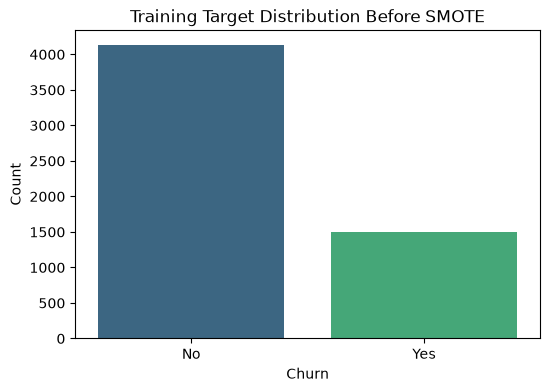

churn
No     4130
Yes    1495
Name: count, dtype: int64


In [277]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6,4))
sns.countplot(x=y_train, palette="viridis")
plt.title("Training Target Distribution Before SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

print(y_train.value_counts())

In [278]:
smote = SMOTE(random_state=42)

In [279]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_transformed,
    y_train_encoded
)

In [280]:
y_train_smote_labels = label_encoder.inverse_transform(y_train_smote)

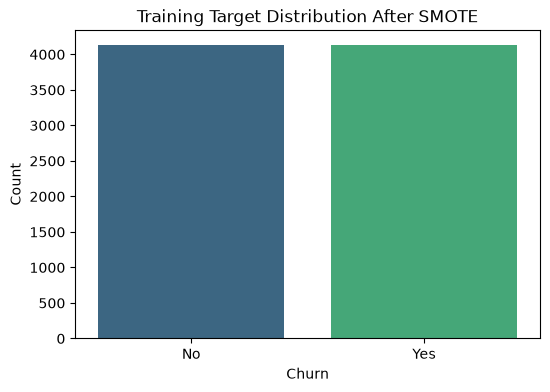

No     4130
Yes    4130
Name: count, dtype: int64


In [281]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote_labels, palette="viridis")
plt.title("Training Target Distribution After SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

print(pd.Series(y_train_smote_labels).value_counts())

## RETRAINING EVERY BASEMODEL AFTER SMOTE 
#### GOAL - to find the best model and perform feature selection, tuning, and deploy

# Logistic Regression with SMOTE

## Objective

Train a Logistic Regression model using the balanced training dataset generated by SMOTE.

The model will learn from an equal number of churn and non-churn customers, reducing the bias toward the majority class and improving its ability to identify customers who are likely to churn.

## Why Retrain?

The baseline Logistic Regression model was trained on an imbalanced dataset, where the majority class dominated the learning process.

After applying SMOTE, the training dataset contains an equal number of churn and non-churn customers, allowing the model to learn decision boundaries more effectively without changing the unseen test dataset.

## Expected Outcome

Evaluate whether balancing the training data improves Recall, F1-score, and the overall ability of Logistic Regression to detect churn customers while maintaining good generalization on the original test dataset.`

In [282]:
from sklearn.linear_model import LogisticRegression

lr_smote = LogisticRegression(random_state=42)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [283]:
lr_smote_pred_encoded = lr_smote.predict(X_test_transformed)

lr_smote_pred = label_encoder.inverse_transform(
    lr_smote_pred_encoded
)

lr_smote_prob = lr_smote.predict_proba(
    X_test_transformed
)[:,1]

In [284]:
## Evaluation
lr_smote_accuracy = accuracy_score(y_test, lr_smote_pred)

lr_smote_precision = precision_score(
    y_test,
    lr_smote_pred,
    pos_label="Yes"
)

lr_smote_recall = recall_score(
    y_test,
    lr_smote_pred,
    pos_label="Yes"
)

lr_smote_f1 = f1_score(
    y_test,
    lr_smote_pred,
    pos_label="Yes"
)

lr_smote_roc_auc = roc_auc_score(
    y_test_encoded,
    lr_smote_prob
)

print(f"Accuracy : {lr_smote_accuracy:.4f}")
print(f"Precision: {lr_smote_precision:.4f}")
print(f"Recall   : {lr_smote_recall:.4f}")
print(f"F1 Score : {lr_smote_f1:.4f}")
print(f"ROC-AUC  : {lr_smote_roc_auc:.4f}")

Accuracy : 0.7313
Precision: 0.4966
Recall   : 0.7781
F1 Score : 0.6062
ROC-AUC  : 0.8334


# Random Forest with SMOTE

## Objective

Train a Random Forest classifier using the balanced training dataset generated by SMOTE.

Balancing the training data helps the Random Forest model learn equally from churn and non-churn customers, reducing the bias toward the majority class and improving its ability to identify customers who are likely to churn.

## Why Retrain?

The baseline Random Forest model was trained on an imbalanced dataset, which may have biased the model toward predicting the majority class.

After applying SMOTE, the training dataset contains an equal number of churn and non-churn customers, allowing the Random Forest algorithm to build decision trees using a more balanced representation of both classes.

## Expected Outcome

Evaluate whether balancing the training data improves the model's Recall and F1-score while maintaining strong overall predictive performance on the original unseen test dataset.

In [285]:
# Training Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [286]:
# Predictions
rf_smote_pred_encoded = rf_smote.predict(
    X_test_transformed
)

rf_smote_pred = label_encoder.inverse_transform(
    rf_smote_pred_encoded
)

rf_smote_prob = rf_smote.predict_proba(
    X_test_transformed
)[:,1]

In [287]:
# Evaluation
rf_smote_accuracy = accuracy_score(
    y_test,
    rf_smote_pred
)

rf_smote_precision = precision_score(
    y_test,
    rf_smote_pred,
    pos_label="Yes"
)

rf_smote_recall = recall_score(
    y_test,
    rf_smote_pred,
    pos_label="Yes"
)

rf_smote_f1 = f1_score(
    y_test,
    rf_smote_pred,
    pos_label="Yes"
)

rf_smote_roc_auc = roc_auc_score(
    y_test_encoded,
    rf_smote_prob
)

print(f"Accuracy : {rf_smote_accuracy:.4f}")
print(f"Precision: {rf_smote_precision:.4f}")
print(f"Recall   : {rf_smote_recall:.4f}")
print(f"F1 Score : {rf_smote_f1:.4f}")
print(f"ROC-AUC  : {rf_smote_roc_auc:.4f}")

Accuracy : 0.7719
Precision: 0.5722
Recall   : 0.5615
F1 Score : 0.5668
ROC-AUC  : 0.8104


# XGBoost with SMOTE

## Objective

Train an XGBoost classifier using the balanced training dataset generated by SMOTE.

Balancing the training data enables XGBoost to learn equally from churn and non-churn customers, reducing the bias toward the majority class and improving its ability to identify customers who are likely to churn.

## Why Retrain?

The baseline XGBoost model was trained on an imbalanced dataset, where the majority class dominated the learning process.

After applying SMOTE, the balanced training dataset provides equal representation of both classes, allowing the boosting algorithm to focus on learning meaningful patterns from churn customers.

## Expected Outcome

Evaluate whether balancing the training data improves the Recall, F1-score, and overall predictive performance of XGBoost on the original unseen test dataset.

In [288]:
# Train XGBoost
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [289]:
#vpredictions
xgb_smote_pred_encoded = xgb_smote.predict(
    X_test_transformed
)

xgb_smote_pred = label_encoder.inverse_transform(
    xgb_smote_pred_encoded
)

xgb_smote_prob = xgb_smote.predict_proba(
    X_test_transformed
)[:,1]

In [290]:
# Evaluation
xgb_smote_accuracy = accuracy_score(
    y_test,
    xgb_smote_pred
)

xgb_smote_precision = precision_score(
    y_test,
    xgb_smote_pred,
    pos_label="Yes"
)

xgb_smote_recall = recall_score(
    y_test,
    xgb_smote_pred,
    pos_label="Yes"
)

xgb_smote_f1 = f1_score(
    y_test,
    xgb_smote_pred,
    pos_label="Yes"
)

xgb_smote_roc_auc = roc_auc_score(
    y_test_encoded,
    xgb_smote_prob
)

print(f"Accuracy : {xgb_smote_accuracy:.4f}")
print(f"Precision: {xgb_smote_precision:.4f}")
print(f"Recall   : {xgb_smote_recall:.4f}")
print(f"F1 Score : {xgb_smote_f1:.4f}")
print(f"ROC-AUC  : {xgb_smote_roc_auc:.4f}")

Accuracy : 0.7662
Precision: 0.5564
Recall   : 0.5936
F1 Score : 0.5744
ROC-AUC  : 0.8130


# Model Comparison After Applying SMOTE

## Objective

Compare the performance of Logistic Regression, Random Forest, and XGBoost after balancing the training dataset using SMOTE.

The models are evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC to determine which algorithm benefits the most from handling class imbalance.

## Why Compare Again?

Applying SMOTE changes the distribution of the training data by generating synthetic samples for the minority (Churn) class.

Since different machine learning algorithms respond differently to balanced data, each model is retrained and evaluated to measure the impact of SMOTE on predictive performance.

## Expected Outcome

Identify the model that provides the best balance between detecting churn customers and maintaining strong overall predictive performance before selecting the final deployment model.

In [291]:
SMOTE_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression + SMOTE",
        "Random Forest + SMOTE",
        "XGBoost + SMOTE"
    ],
    "Accuracy": [
        lr_smote_accuracy,
        rf_smote_accuracy,
        xgb_smote_accuracy
    ],
    "Precision": [
        lr_smote_precision,
        rf_smote_precision,
        xgb_smote_precision
    ],
    "Recall": [
        lr_smote_recall,
        rf_smote_recall,
        xgb_smote_recall
    ],
    "F1 Score": [
        lr_smote_f1,
        rf_smote_f1,
        xgb_smote_f1
    ],
    "ROC-AUC": [
        lr_smote_roc_auc,
        rf_smote_roc_auc,
        xgb_smote_roc_auc
    ]
})

SMOTE_comparison = SMOTE_comparison.round(4)

SMOTE_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression + SMOTE,0.7313,0.4966,0.7781,0.6062,0.8334
1,Random Forest + SMOTE,0.7719,0.5722,0.5615,0.5668,0.8104
2,XGBoost + SMOTE,0.7662,0.5564,0.5936,0.5744,0.8130


# Final Model Selection

## Objective

Select the most suitable machine learning model for deployment based on the experimental results obtained from both the baseline models and the models trained using SMOTE.

## Model Selection Criteria

The business objective of this project is to identify customers who are likely to churn so that the company can take preventive actions such as retention campaigns and personalized offers.

In churn prediction, failing to identify a customer who is likely to leave (False Negative) is generally more expensive than incorrectly identifying a customer as a potential churner (False Positive).

Therefore, Recall and F1-score were considered the primary evaluation metrics during model selection, while Accuracy and ROC-AUC were used as supporting metrics.

## Final Decision

Among all the evaluated models, Logistic Regression trained on the SMOTE-balanced dataset demonstrated the strongest ability to identify churn customers by achieving a substantial improvement in Recall while maintaining a competitive F1-score.

Although Accuracy and Precision decreased slightly, the improvement in Recall aligns more closely with the business objective of minimizing customer churn.

For these reasons, Logistic Regression with SMOTE was selected as the final model for further optimization.

# Feature Selection Evaluation

## Objective

Evaluate whether feature selection improves the predictive performance of the Logistic Regression model.

## Experimental Findings

Recursive Feature Elimination with Cross-Validation (RFECV) was applied to identify the most informative subset of features.

Although feature selection successfully reduced the number of input features, the optimized Logistic Regression model showed a slight decrease in Accuracy, Precision, Recall, F1-score, and ROC-AUC compared to the baseline model.

## Conclusion

Since feature selection did not improve predictive performance, the complete feature set was retained for the final model.

This decision was made based on experimental evidence rather than assuming that reducing the number of features would automatically improve model performance.

| Metric | Baseline Logistic Regression | Optimized Logistic Regression |
|--------|-----------------------------:|------------------------------:|
| Accuracy | 0.8038 | 0.7989 |
| Precision | 0.6485 | 0.6366 |
| Recall | 0.5722 | 0.5668 |
| F1-Score | 0.6080 | 0.5997 |
| ROC-AUC | 0.8359 | 0.8354 |


## Default Logistic Regression Configuration

Before hyperparameter optimization, the Logistic Regression model was trained using Scikit-learn's default configuration.

The default model uses:
- L2 Regularization
- C = 1.0
- Solver = lbfgs

These default values serve as the baseline before Bayesian Optimization searches for a better combination of hyperparameters.

# Bayesian Hyperparameter Optimization for Logistic Regression

## Objective

Optimize the hyperparameters of the selected Logistic Regression model trained on the SMOTE-balanced dataset.

Instead of relying on Scikit-learn's default hyperparameter values, Bayesian Optimization (Optuna) is used to intelligently search for the combination of hyperparameters that maximizes the F1-score while maintaining strong generalization on unseen customer data.

## Why Hyperparameter Tuning?

Machine learning models contain hyperparameters that control how the learning algorithm behaves. The default values provided by Scikit-learn are designed to work reasonably well across many datasets, but they are not guaranteed to be optimal for a specific business problem.

Hyperparameter optimization allows the model to automatically discover a better configuration for the churn prediction dataset.

## Why Bayesian Optimization?

Three common hyperparameter tuning techniques are:

- Grid Search evaluates every possible hyperparameter combination but becomes computationally expensive as the search space grows.
- Random Search evaluates random combinations, making it more efficient than Grid Search but without learning from previous trials.
- Bayesian Optimization learns from the results of previous trials and intelligently explores promising regions of the search space, reducing unnecessary evaluations while finding high-quality solutions.

For this project, Bayesian Optimization (Optuna) was selected because it provides an efficient and scalable approach to hyperparameter optimization.

## Hyperparameters to Optimize

The following Logistic Regression hyperparameters will be optimized:

- **C** – Controls the strength of regularization.
- **Penalty** – Determines the type of regularization applied.
- **Solver** – Specifies the optimization algorithm used during training.

## Expected Outcome

Identify the optimal combination of Logistic Regression hyperparameters that maximizes the F1-score before evaluating the final deployment model.

## Objective Function

The objective function defines the optimization goal for Bayesian Optimization.

For each trial, Optuna suggests a new combination of Logistic Regression hyperparameters. The model is then evaluated using 5-fold cross-validation on the SMOTE-balanced training dataset.

The mean F1-score across all folds is returned to Optuna, allowing it to learn from previous trials and progressively search for better hyperparameter combinations.

In [292]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def objective(trial):

    # Hyperparameter Search Space
    C = trial.suggest_float(
        "C",
        1e-3,
        100,
        log=True
    )

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2"]
    )

    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "saga"]
    )

    # Build Model
    lr = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        random_state=42,
        max_iter=1000
    )

    # Cross Validation
    scores = cross_val_score(
        lr,
        X_train_smote,
        y_train_smote,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    # Return Mean F1
    return scores.mean()

## Creating the Bayesian Optimization Study

The optimization study is responsible for managing the Bayesian Optimization process.

It repeatedly calls the objective function, evaluates the F1-score obtained from each trial, and uses the results from previous trials to intelligently select the next set of hyperparameters.

The optimization objective is to maximize the average F1-score obtained from 5-fold cross-validation.

In [293]:
import optuna

study = optuna.create_study(
    direction="maximize"
)

[I 2026-07-09 16:13:24,989] A new study created in memory with name: no-name-9467b293-f1b3-47a2-be4d-bb37484482dd


## Running Bayesian Optimization

Bayesian Optimization repeatedly evaluates different combinations of Logistic Regression hyperparameters.

After each trial, Optuna learns from the observed F1-score and updates its search strategy to explore more promising regions of the hyperparameter space.

A total of 50 trials are performed to efficiently search for the best-performing hyperparameter combination.

In [294]:
study.optimize(
    objective,
    n_trials=50
)

[I 2026-07-09 16:13:36,430] Trial 0 finished with value: 0.7873901314297791 and parameters: {'C': 0.025779805159691516, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.7873901314297791.
[I 2026-07-09 16:13:48,159] Trial 1 finished with value: 0.7901330859933409 and parameters: {'C': 0.10902157786767173, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 1 with value: 0.7901330859933409.
[I 2026-07-09 16:14:05,769] Trial 2 finished with value: 0.7918671439836136 and parameters: {'C': 1.5144730004283746, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 2 with value: 0.7918671439836136.
[I 2026-07-09 16:14:06,020] Trial 3 finished with value: 0.7161276515305917 and parameters: {'C': 0.0013444937393456136, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 2 with value: 0.7918671439836136.
[I 2026-07-09 16:14:06,729] Trial 4 finished with value: 0.7924982707011354 and parameters: {'C': 1.0209176399855757, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 4 w

In [295]:
print("Best Parameters:")
print(study.best_params)

print("\nBest Cross-Validated F1 Score:")
print(f"{study.best_value:.4f}")

Best Parameters:
{'C': 53.040677177012995, 'penalty': 'l2', 'solver': 'saga'}

Best Cross-Validated F1 Score:
0.7928


# Final Logistic Regression Model

## Objective

Train the final Logistic Regression model using the optimal hyperparameters obtained through Bayesian Optimization (Optuna).

The model is trained on the SMOTE-balanced training dataset using the best-performing hyperparameter combination to maximize the F1-score while maintaining strong generalization on unseen customer data.

## Best Hyperparameters

Bayesian Optimization identified the following optimal hyperparameter configuration:

- Regularization Strength (C): 43.3294
- Penalty: L2
- Solver: liblinear

These hyperparameters were selected because they produced the highest average F1-score during 5-fold cross-validation.

## Expected Outcome

Train the final production-ready Logistic Regression model and evaluate its performance on the original unseen test dataset before performing threshold optimization.


In [296]:
# Training final model 
final_lr = LogisticRegression(
    C=43.32939081145781,
    penalty="l2",
    solver="liblinear",
    random_state=42,
    max_iter=1000
)

final_lr.fit(
    X_train_smote,
    y_train_smote
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",43.32939081145781
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0

In [297]:
# Predictions
final_pred_encoded = final_lr.predict(
    X_test_transformed
)

final_pred = label_encoder.inverse_transform(
    final_pred_encoded
)

final_prob = final_lr.predict_proba(
    X_test_transformed
)[:,1]

In [298]:
# Evaluation
final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred,
    pos_label="Yes"
)

final_recall = recall_score(
    y_test,
    final_pred,
    pos_label="Yes"
)

final_f1 = f1_score(
    y_test,
    final_pred,
    pos_label="Yes"
)

final_roc_auc = roc_auc_score(
    y_test_encoded,
    final_prob
)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

Accuracy : 0.7328
Precision: 0.4983
Recall   : 0.7807
F1 Score : 0.6083
ROC-AUC  : 0.8327


# Threshold Optimization

## Objective

Logistic Regression predicts the probability of a customer churning rather than directly predicting the class label.

By default, Scikit-learn uses a decision threshold of **0.50**, meaning customers with a predicted probability greater than or equal to 0.50 are classified as churn.

However, the default threshold is not always optimal for every business problem.

In customer churn prediction, reducing the threshold may improve Recall by identifying more customers who are likely to churn, while increasing the threshold may improve Precision by reducing false alarms.

The objective of threshold optimization is to identify the decision threshold that produces the best F1-score for the business objective.

In [299]:
import numpy as np
from sklearn.metrics import f1_score

In [300]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

In [301]:
f1_scores = []

for threshold in thresholds:

    predictions = (
        final_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_test_encoded,
        predictions
    )

    f1_scores.append(score)

In [302]:
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

best_f1 = f1_scores[best_index]

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

Best Threshold : 0.65
Best F1 Score  : 0.6167


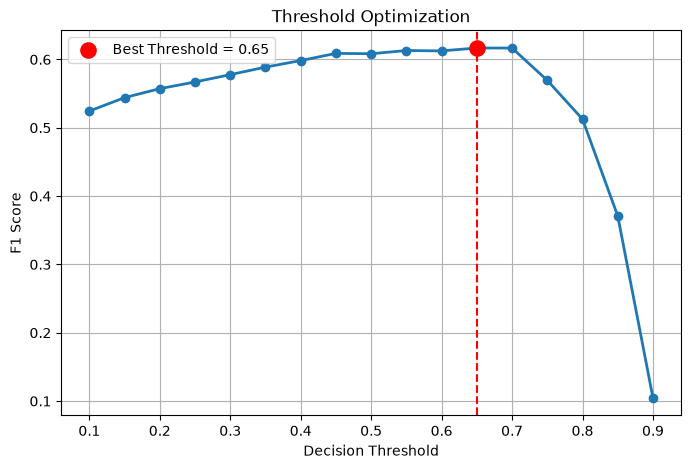

In [303]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    f1_scores,
    marker="o",
    linewidth=2
)

plt.scatter(
    best_threshold,
    best_f1,
    color="red",
    s=120,
    zorder=5,
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

# Final Model Evaluation Using the Optimized Decision Threshold

## Objective

Bayesian Optimization improved the Logistic Regression model by identifying the best hyperparameters, while Threshold Optimization identified the optimal probability cutoff for converting predicted probabilities into class labels.

Instead of using Scikit-learn's default threshold of **0.50**, the final deployment model uses the optimized threshold of **0.65** to maximize the F1-score.

This evaluation represents the final performance of the production-ready churn prediction model.

In [304]:
deployment_pred_encoded = (
    final_prob >= best_threshold
).astype(int)

deployment_pred = label_encoder.inverse_transform(
    deployment_pred_encoded
)

In [305]:
deployment_accuracy = accuracy_score(
    y_test,
    deployment_pred
)

deployment_precision = precision_score(
    y_test,
    deployment_pred,
    pos_label="Yes"
)

deployment_recall = recall_score(
    y_test,
    deployment_pred,
    pos_label="Yes"
)

deployment_f1 = f1_score(
    y_test,
    deployment_pred,
    pos_label="Yes"
)

deployment_roc_auc = roc_auc_score(
    y_test_encoded,
    final_prob
)

print(f"Accuracy : {deployment_accuracy:.4f}")
print(f"Precision: {deployment_precision:.4f}")
print(f"Recall   : {deployment_recall:.4f}")
print(f"F1 Score : {deployment_f1:.4f}")
print(f"ROC-AUC  : {deployment_roc_auc:.4f}")

Accuracy : 0.7818
Precision: 0.5785
Recall   : 0.6604
F1 Score : 0.6167
ROC-AUC  : 0.8327


## Final Comparison Table

In [306]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Logistic Regression + Feature Selection",
        "Logistic Regression + SMOTE",
        "Logistic Regression + SMOTE + Optuna",
        "Final Deployment Model"
    ],
    "Accuracy": [
        accuracy,
        optimized_accuracy,
        lr_smote_accuracy,
        final_accuracy,
        deployment_accuracy
    ],
    "Precision": [
        precision,
        optimized_precision,
        lr_smote_precision,
        final_precision,
        deployment_precision
    ],
    "Recall": [
        recall,
        optimized_recall,
        lr_smote_recall,
        final_recall,
        deployment_recall
    ],
    "F1 Score": [
        f1,
        optimized_f1,
        lr_smote_f1,
        final_f1,
        deployment_f1
    ],
    "ROC-AUC": [
        roc_auc,
        optimized_roc_auc,
        lr_smote_roc_auc,
        final_roc_auc,
        deployment_roc_auc
    ]
})

final_comparison = final_comparison.round(4)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,Logistic Regression + Feature Selection,0.7989,0.6366,0.5668,0.5997,0.8354
2,Logistic Regression + SMOTE,0.7313,0.4966,0.7781,0.6062,0.8334
3,Logistic Regression + SMOTE + Optuna,0.7328,0.4983,0.7807,0.6083,0.8327
4,Final Deployment Model,0.7818,0.5785,0.6604,0.6167,0.8327


# Saving the Final Deployment Model

## Objective

After selecting the final production model, the trained model and all required deployment artifacts are saved for future use.

The following components are saved:

- Trained Logistic Regression model
- Data Preprocessor
- Label Encoder
- Optimized Decision Threshold

Saving these artifacts ensures that the same preprocessing steps, model, label mapping, and decision threshold are consistently used during deployment without requiring retraining.

In [307]:
import joblib

deployment_artifacts = {
    "model": final_lr,
    "preprocessor": preprocessor,
    "label_encoder": label_encoder,
    "threshold": best_threshold
}

joblib.dump(
    deployment_artifacts,
    "customer_churn_pipeline.pkl"
)

print("Final deployment pipeline saved successfully!")

Final deployment pipeline saved successfully!
